In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv("drug200.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [5]:
df["Drug"].value_counts()

Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

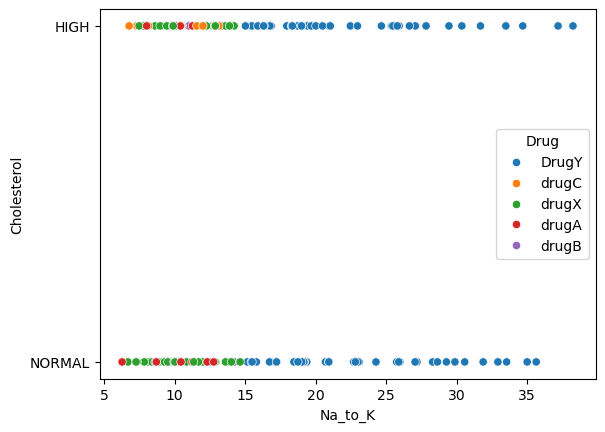

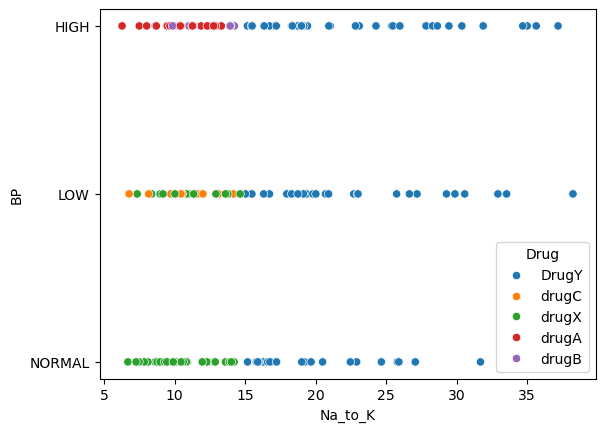

In [6]:
sns.scatterplot(x=df["Na_to_K"], y=df["Cholesterol"], hue=df["Drug"])
plt.show()
sns.scatterplot(x=df["Na_to_K"], y=df["BP"], hue=df["Drug"])
plt.show()

In [7]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [8]:
from sklearn.preprocessing import LabelEncoder

le_Sex = LabelEncoder()
le_BP = LabelEncoder()
le_Cholesterol = LabelEncoder()

In [9]:
df["Sex"] = le_Sex.fit_transform(df["Sex"])
df["BP"] = le_BP.fit_transform(df["BP"])
df["Cholesterol"] = le_Cholesterol.fit_transform(df["Cholesterol"])

In [10]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,DrugY
1,47,1,1,0,13.093,drugC
2,47,1,1,0,10.114,drugC
3,28,0,2,0,7.798,drugX
4,61,0,1,0,18.043,DrugY


In [11]:
X = df[["Age", "Sex", "BP", "Cholesterol", "Na_to_K"]].values
y = df["Drug"].values

In [12]:
y

array(['DrugY', 'drugC', 'drugC', 'drugX', 'DrugY', 'drugX', 'DrugY',
       'drugC', 'DrugY', 'DrugY', 'drugC', 'DrugY', 'DrugY', 'DrugY',
       'drugX', 'DrugY', 'drugX', 'drugA', 'drugC', 'DrugY', 'DrugY',
       'DrugY', 'DrugY', 'DrugY', 'DrugY', 'DrugY', 'DrugY', 'drugX',
       'DrugY', 'DrugY', 'drugX', 'drugB', 'drugX', 'DrugY', 'drugX',
       'drugX', 'drugA', 'drugX', 'drugX', 'drugX', 'DrugY', 'drugB',
       'DrugY', 'drugX', 'drugX', 'drugX', 'drugA', 'drugC', 'DrugY',
       'DrugY', 'DrugY', 'drugX', 'DrugY', 'DrugY', 'drugB', 'drugC',
       'drugB', 'DrugY', 'drugX', 'DrugY', 'DrugY', 'drugA', 'DrugY',
       'drugX', 'drugB', 'DrugY', 'drugA', 'drugX', 'DrugY', 'DrugY',
       'drugB', 'DrugY', 'drugX', 'DrugY', 'DrugY', 'DrugY', 'drugA',
       'DrugY', 'drugA', 'drugX', 'drugB', 'drugX', 'drugC', 'drugA',
       'drugC', 'drugB', 'drugX', 'DrugY', 'DrugY', 'DrugY', 'DrugY',
       'DrugY', 'DrugY', 'DrugY', 'DrugY', 'drugX', 'DrugY', 'DrugY',
       'DrugY', 'Dru

In [13]:
le = LabelEncoder()
y = le.fit_transform(y)
for i, label in enumerate(le.classes_): 
    print(i, "->", label)

0 -> DrugY
1 -> drugA
2 -> drugB
3 -> drugC
4 -> drugX


In [14]:
y

array([0, 3, 3, 4, 0, 4, 0, 3, 0, 0, 3, 0, 0, 0, 4, 0, 4, 1, 3, 0, 0, 0,
       0, 0, 0, 0, 0, 4, 0, 0, 4, 2, 4, 0, 4, 4, 1, 4, 4, 4, 0, 2, 0, 4,
       4, 4, 1, 3, 0, 0, 0, 4, 0, 0, 2, 3, 2, 0, 4, 0, 0, 1, 0, 4, 2, 0,
       1, 4, 0, 0, 2, 0, 4, 0, 0, 0, 1, 0, 1, 4, 2, 4, 3, 1, 3, 2, 4, 0,
       0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 1, 1, 3, 4, 0, 4, 4, 0, 2, 0,
       1, 4, 4, 4, 4, 0, 4, 4, 1, 0, 0, 0, 0, 0, 2, 0, 0, 4, 0, 4, 0, 0,
       4, 0, 0, 4, 2, 1, 2, 4, 1, 0, 2, 0, 1, 4, 4, 1, 4, 3, 1, 2, 4, 4,
       0, 3, 1, 0, 3, 4, 4, 2, 4, 0, 0, 0, 0, 4, 0, 1, 4, 4, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 4, 4, 0, 0, 0, 2, 1, 0, 0, 0, 1, 0, 3, 0, 3, 3, 4,
       4, 4])

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() 
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)

In [17]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

In [18]:
from torch import nn
class DrugClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(5, 64), 
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32,5)
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

In [19]:
model = DrugClassifier()
model = torch.compile(model)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [20]:
def calculate_accuracy(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() 
    acc = (correct / len(y_pred)) * 100 
    return acc

In [21]:
model = DrugClassifier()

In [22]:
model(X_test)[:5]

tensor([[-0.0115,  0.0344, -0.0744,  0.0195,  0.1476],
        [-0.0475,  0.1059,  0.1471,  0.2303, -0.0707],
        [-0.0670,  0.0217, -0.0332,  0.0641,  0.1072],
        [-0.0070, -0.0645,  0.0645,  0.0764,  0.0803],
        [ 0.0884,  0.1164,  0.0318,  0.1436,  0.0295]],
       grad_fn=<SliceBackward0>)

In [23]:
model(X_test)[0].shape

torch.Size([5])

In [24]:
y_logits = model(X_test)
y_pred_probs = torch.softmax(y_logits, dim=1) 
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-0.0115,  0.0344, -0.0744,  0.0195,  0.1476],
        [-0.0475,  0.1059,  0.1471,  0.2303, -0.0707],
        [-0.0670,  0.0217, -0.0332,  0.0641,  0.1072],
        [-0.0070, -0.0645,  0.0645,  0.0764,  0.0803],
        [ 0.0884,  0.1164,  0.0318,  0.1436,  0.0295]],
       grad_fn=<SliceBackward0>)
tensor([[0.1927, 0.2017, 0.1809, 0.1987, 0.2259],
        [0.1761, 0.2053, 0.2140, 0.2325, 0.1721],
        [0.1832, 0.2002, 0.1895, 0.2089, 0.2181],
        [0.1924, 0.1817, 0.2067, 0.2092, 0.2100],
        [0.2011, 0.2068, 0.1900, 0.2125, 0.1896]], grad_fn=<SliceBackward0>)


In [25]:
torch.sum(y_pred_probs[0])

tensor(1., grad_fn=<SumBackward0>)

In [26]:
print(y_pred_probs[0]) #ilk örnek tahmini
print(torch.argmax(y_pred_probs[0])) #en büyüğünün indeksi

tensor([0.1927, 0.2017, 0.1809, 0.1987, 0.2259], grad_fn=<SelectBackward0>)
tensor(4)


In [27]:
epochs = 100
model = DrugClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
for epoch in range(epochs):
    model.train()
    logits = model(X_train)
    loss = loss_fn(logits, y_train)

    pred = torch.argmax(logits, dim=1)
    acc = calculate_accuracy(y_train, pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_pred = torch.argmax(test_logits, dim=1)
        test_acc = calculate_accuracy(y_test, test_pred)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch 0 | Loss: 1.5439 | Acc: 25.00% | Test Loss: 1.4126 | Test Acc: 57.50%
Epoch 10 | Loss: 0.5080 | Acc: 80.00% | Test Loss: 0.5738 | Test Acc: 72.50%
Epoch 20 | Loss: 0.1281 | Acc: 98.75% | Test Loss: 0.2954 | Test Acc: 92.50%
Epoch 30 | Loss: 0.0295 | Acc: 99.38% | Test Loss: 0.1639 | Test Acc: 95.00%
Epoch 40 | Loss: 0.0120 | Acc: 100.00% | Test Loss: 0.1286 | Test Acc: 97.50%
Epoch 50 | Loss: 0.0066 | Acc: 100.00% | Test Loss: 0.1296 | Test Acc: 97.50%
Epoch 60 | Loss: 0.0044 | Acc: 100.00% | Test Loss: 0.1253 | Test Acc: 97.50%
Epoch 70 | Loss: 0.0033 | Acc: 100.00% | Test Loss: 0.1314 | Test Acc: 97.50%
Epoch 80 | Loss: 0.0026 | Acc: 100.00% | Test Loss: 0.1320 | Test Acc: 97.50%
Epoch 90 | Loss: 0.0022 | Acc: 100.00% | Test Loss: 0.1322 | Test Acc: 97.50%


In [28]:
from torchmetrics.classification import MulticlassConfusionMatrix

In [29]:
cm = MulticlassConfusionMatrix(num_classes=5)
matrix = cm(test_pred, y_test)

In [30]:
print(matrix)

tensor([[17,  0,  0,  0,  1],
        [ 0,  5,  0,  0,  0],
        [ 0,  0,  3,  0,  0],
        [ 0,  0,  0,  3,  0],
        [ 0,  0,  0,  0, 11]])


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

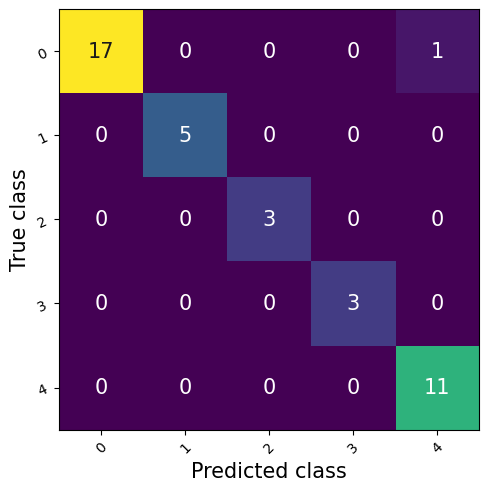

In [31]:
from torchmetrics.utilities.plot import plot_confusion_matrix
plot_confusion_matrix(matrix)

In [32]:
!pip install joblib

In [33]:
import joblib

# Scaler nesnesini bir dosyaya yazıyoruz
joblib.dump(scaler, "scaler.joblib")
print("Scaler başarıyla kaydedildi!")

Scaler başarıyla kaydedildi!


In [34]:
from pathlib import Path

In [35]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "drug_classification_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)

In [36]:
model.state_dict()

OrderedDict([('linear_layer_stack.0.weight',
              tensor([[-0.7977,  0.1434, -0.3479, -0.5091,  0.2521],
                      [ 0.5693, -0.3639,  0.5708,  0.1913,  0.4587],
                      [ 0.3660, -0.3247, -0.2854,  0.3118,  0.6756],
                      [ 0.5625,  0.5477,  0.4875,  0.2179,  0.3153],
                      [ 0.4407, -0.1474,  0.5152,  0.2155, -0.3988],
                      [ 0.0500,  0.2885, -0.3408,  0.0406, -0.2251],
                      [-0.0428,  0.1438, -0.5001, -0.3121,  0.5096],
                      [ 0.1156,  0.1360,  0.2186, -0.1334,  0.1848],
                      [-0.5830,  0.0293,  0.1244, -0.1989, -0.7013],
                      [ 0.0851,  0.1097,  0.7397,  0.3327, -0.6662],
                      [-0.0631, -0.0069, -0.6195,  0.5624, -0.4718],
                      [-0.5874, -0.1826,  0.7549,  0.0718, -0.4031],
                      [ 0.6821,  0.0630, -0.4424, -0.1512, -0.1491],
                      [ 0.2253,  0.0834,  0.2662, -0.0451,

In [37]:
loaded_model = DrugClassifier()

In [38]:
type(torch.load(MODEL_SAVE_PATH))

collections.OrderedDict

In [39]:
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>